In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf

[*********************100%***********************]  1 of 1 completed


<Axes: >

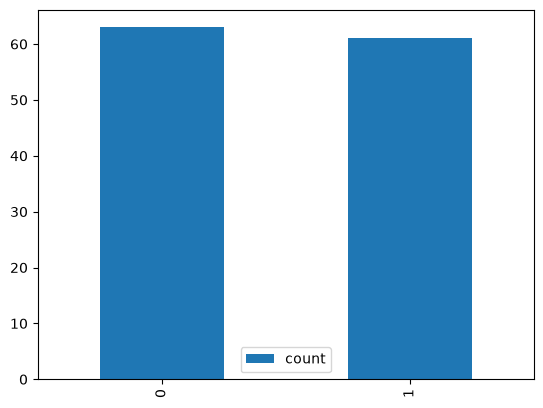

In [2]:
# Normal Frequency Table
data = yf.download(tickers='AAPL',start='2024-01-01',end='2024-06-30')
# right  do not have categorical data

# so categorical column data
data['Daily Returns']  = data['Close'].pct_change()
data['Categries of Daily Returns'] = data['Daily Returns'].apply(lambda x: "Positive" if x > 0 else "Negative")

# .value_counts() - Har value kitni baar aayi count karta hai:
freq = data['Categries of Daily Returns'].value_counts().reset_index()
freq.plot(kind='bar')


<Axes: >

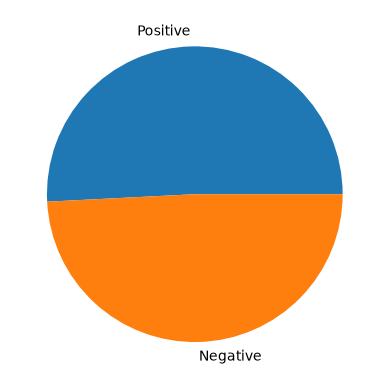

In [3]:
# Relative frequency - Relative Frequency = Frequency / Total observations
# Frequency (absolute count)	Positive = 63
# Relative Frequency	Positive = 63/124 = 0.508
# Percentage Frequency	Positive = 50.8%

# normalize=True - raw count nahi
# proportion (percentage ratio) do
# Positive = 63/124 = 0.508065
# Negative = 61/124 = 0.491935
# .reset_index() - Index ko normal column bana deta hai
# Positive → market 50.8% days upar gaya
# Negative → market 49.2% days niche gaya
# AI trading project mein iska use:

# Market bias detect karna
# Dataset balanced hai ya nahi dekhna
# ML classification se pehle target distribution check karna
# data['Categries of Daily Returns'].value_counts(normalize=True).reset_index()
# or
# data['Categries of Daily Returns'].value_counts(normalize=True).mul(100).round(2)
data['Categries of Daily Returns'].value_counts(normalize=True).plot(kind='pie')

In [ ]:
# Cumulative frequency
data['Categries of Daily Returns'].value_counts(normalize=True).reset_index().cumsum()

,Categries of Daily Returns,proportion
0,Positive,0.508065
1,PositiveNegative,1.000000


: 

<Axes: >

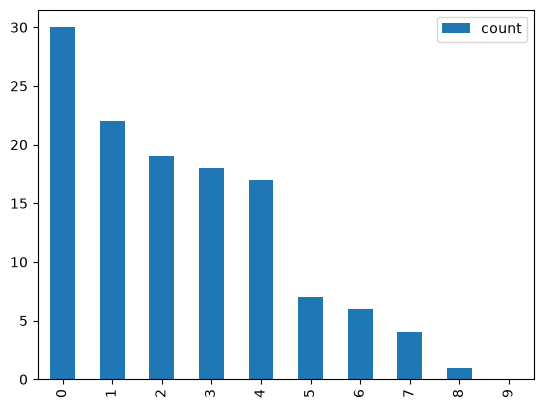

In [ ]:
# Numerical Column
# pd.cut(data['Close'],bins=10).value_counts().reset_index().plot(kind='bar')
# data
# data['Close']
# pd.cut(data['Close'],bins=10)
# pd.cut() - Ye continuous values ko groups / intervals (bins) mein divide karta hai.
# Suppose prices:

# 100
# 120
# 145
# 180
# 200
# 220
# 250

# Aur:

# pd.cut(price,bins=3)

# Internally:

# (99,150]
# (150,200]
# (200,250]

# Output:

# 100 → (99,150]
# 120 → (99,150]
# 145 → (99,150]
# 180 → (150,200]
# 220 → (200,250]

# Use case in AI trading:

# Stock prices ko ranges mein convert karna
# Feature engineering
# Risk categories banana
# ML mein bahut use hota hai jab continuous values ko categories mein convert karna hota ha
pd.cut(data[('Close','AAPL')], bins=10).value_counts().reset_index().plot(kind='bar')  #- it will draw bar chart


(array([22., 18.,  4., 30., 19., 17.,  1.,  0.,  6.,  7.]),
 array([163.36140442, 168.50618439, 173.65096436, 178.79574432,
        183.94052429, 189.08530426, 194.23008423, 199.3748642 ,
        204.51964417, 209.66442413, 214.8092041 ]),
 <BarContainer object of 10 artists>)

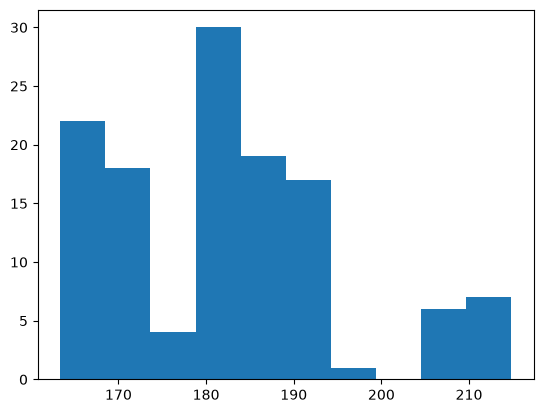

In [ ]:
# historgram 
# if more bins provided - then it will not give good result - balanced bins must be provided
plt.hist(data[('Close','AAPL')], bins=10)